In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rkhs import RKHS

In [2]:
# Generate synthetic data on the interval [0,1]
# Here we define a smooth function for demonstration purposes.
x = np.linspace(0, 1, 50)
# Example function: f(x) = sin(2πx) + 0.5*cos(3πx)
f_values = np.sin(2 * np.pi * x) + 0.5 * np.cos(3 * np.pi * x)
data_series = np.column_stack((x, f_values))
data_series[:5]

array([[0.        , 0.5       ],
       [0.02040816, 0.61865674],
       [0.04081633, 0.71711296],
       [0.06122449, 0.79431106],
       [0.08163265, 0.84989223]])

In [3]:
# Create an RKHS object with m basis functions and a specified fractal depth.
m = 5
fractal_depth = 2
rkhs_obj = RKHS(data_series=data_series, m=m, fractal_depth=fractal_depth)

Vertical scaling factors s_values were not provided, so they were initialised randomly.
Building the Basis functions for the RKHS:
	Built u_1.
S_arr shape: (50, 2)
Iteration: 0 S_arr shape: (50, 2)
Iteration: 1 S_arr shape: (2450, 2)
Iteration: 1 S_arr shape: (120050, 2)
	Built F_[u_1].
	Number of points for basis F_[u_1] = (120050,)
	Built u_2.
S_arr shape: (50, 2)
Iteration: 0 S_arr shape: (50, 2)
Iteration: 1 S_arr shape: (2450, 2)
Iteration: 1 S_arr shape: (120050, 2)
	Built F_[u_2].
	Number of points for basis F_[u_2] = (120050,)
	Built u_3.
S_arr shape: (50, 2)
Iteration: 0 S_arr shape: (50, 2)
Iteration: 1 S_arr shape: (2450, 2)
Iteration: 1 S_arr shape: (120050, 2)
	Built F_[u_3].
	Number of points for basis F_[u_3] = (120050,)
	Built u_4.
S_arr shape: (50, 2)
Iteration: 0 S_arr shape: (50, 2)
Iteration: 1 S_arr shape: (2450, 2)
Iteration: 1 S_arr shape: (120050, 2)
	Built F_[u_4].
	Number of points for basis F_[u_4] = (120050,)
	Built u_5.
S_arr shape: (50, 2)
Iteration: 0 S_a

In [4]:
# Print out the matrix A (inner products) and its inverse B.
print("Matrix A (inner products between fractal basis functions):")
print(rkhs_obj.A)
print("\nMatrix B (inverse of A):")
print(rkhs_obj.B)

Matrix A (inner products between fractal basis functions):
[[ 1.1427967   0.00276246  0.09764272  0.00635308 -0.01732286]
 [ 0.00276246  0.51114988  0.02509923  0.00512104  0.00501086]
 [ 0.09764272  0.02509923  1.4281213   0.09268042 -0.04490493]
 [ 0.00635308  0.00512104  0.09268042  0.73862921 -0.08064327]
 [-0.01732286  0.00501086 -0.04490493 -0.08064327  0.98575168]]

Matrix B (inverse of A):
[[ 8.80351334e-01 -1.95912887e-03 -5.98398439e-02  1.35465137e-03
   1.28654704e-02]
 [-1.95912887e-03  1.95828091e+00 -3.39817692e-02 -1.06510553e-02
  -1.24082997e-02]
 [-5.98398439e-02 -3.39817692e-02  7.11248990e-01 -8.58195958e-02
   2.45005879e-02]
 [ 1.35465137e-03 -1.06510553e-02 -8.58195958e-02  1.37656677e+00
   1.08783942e-01]
 [ 1.28654704e-02 -1.24082997e-02  2.45005879e-02  1.08783942e-01
   1.02475903e+00]]


In [5]:
np.linalg.eigvals(rkhs_obj.A)

array([1.47701549, 1.11375941, 0.99902685, 0.70632833, 0.51031869])


Kernel function k(1, 1) = 4.944547294764172


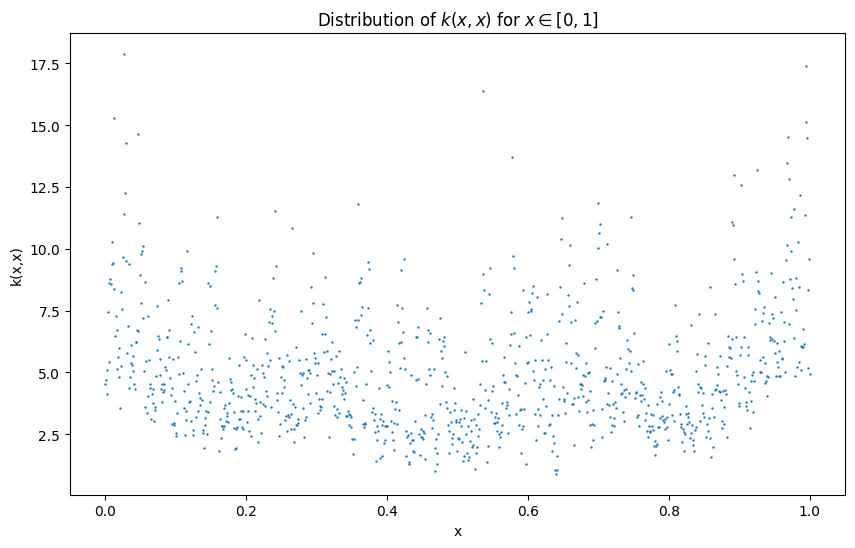

In [6]:
# Evaluate the kernel function between two sample points.
x1 = 1
x2 = 1
k_val = rkhs_obj.kernel_function(x1, x2)
print(f"\nKernel function k({x1}, {x2}) = {k_val}")
x_plot = np.linspace(0, 1, 1000)
plt.figure(figsize=(10, 6))

kf = np.array([rkhs_obj.kernel_function(x,x) for x in x_plot])
# rkhs_obj.kernel_array(x_plot, x_plot)
plt.scatter(x_plot, kf, s=0.5)
plt.title(r"Distribution of $k(x, x)$ for $x \in [0, 1]$")
plt.xlabel("x")
plt.ylabel("k(x,x)")
plt.show()


Kernel function k(1, 1) = 4.944547294764172


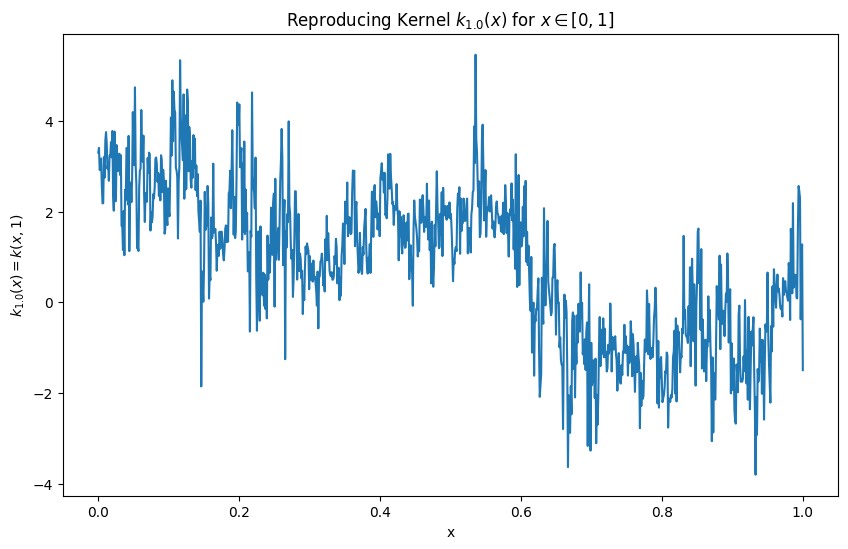

In [13]:
# Evaluate the kernel function between two sample points.
x1 = 1
x2 = 1
k_val = rkhs_obj.kernel_function(x1, x2)
print(f"\nKernel function k({x1}, {x2}) = {k_val}")
x_plot = np.linspace(0, 1, 1000)
def reproducing_kernel(x_):
    return lambda x: rkhs_obj.kernel_array(x, (np.zeros_like(x)+x_))

y_plot = reproducing_kernel(0.2)(x_plot)
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot)
plt.title(r"Reproducing Kernel $k_{1.0}(x)$ for $x \in [0, 1]$")
plt.xlabel("x")
plt.ylabel(r"$k_{1.0}(x) = k(x,1)$")
plt.show()

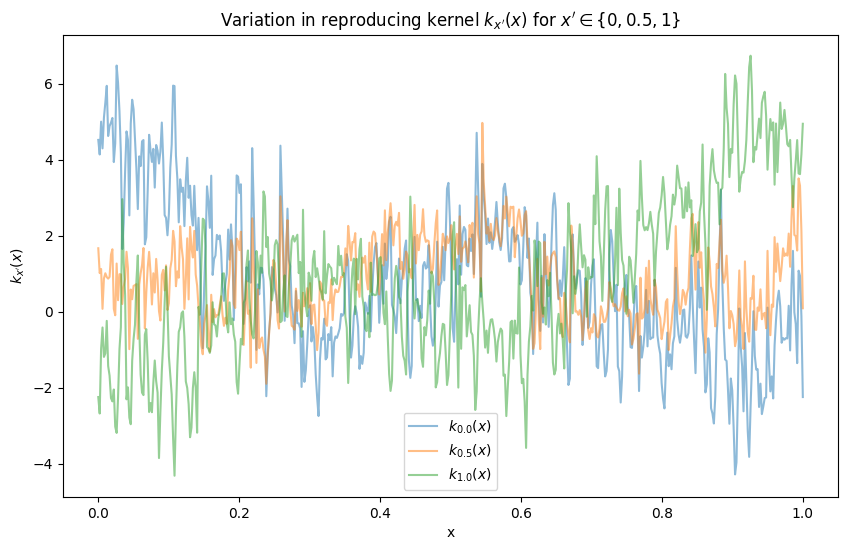

In [18]:
x_plot = np.linspace(0, 1, 500)
plt.figure(figsize=(10, 6))
for i in range(3):
    x_ = i/2.0
    y_plot = reproducing_kernel(x_)(x_plot)
    x_str = f"{x_}"
    label_str = r"$k_{"
    label_str += x_str
    label_str += r"}(x)$"
    plt.plot(x_plot, y_plot, label=label_str, alpha=0.5)
plt.title(r"Variation in reproducing kernel $k_{x'}(x)$ for $x' \in \{0, 0.5, 1\}$")
plt.xlabel("x")
plt.ylabel(r"$k_{x'}(x)$")
plt.legend()
plt.show()

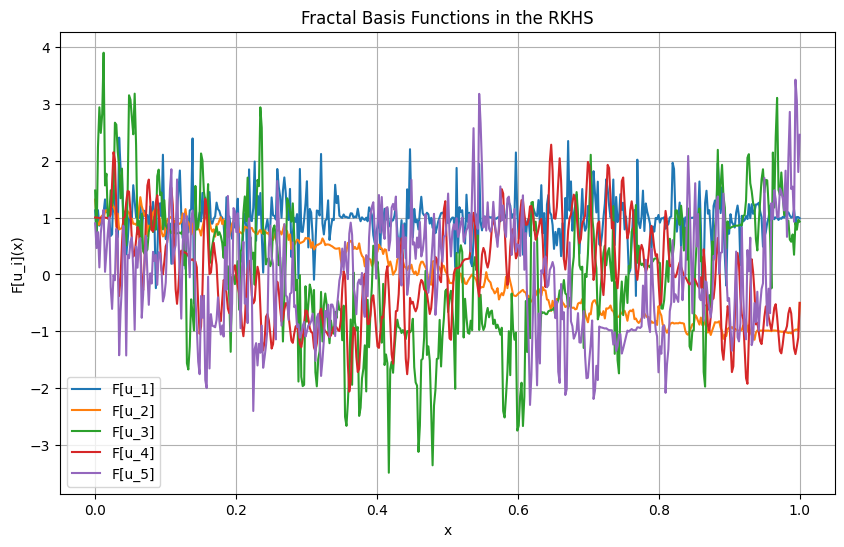

In [ ]:
# Plot the fractal basis functions over the interval [0, 1].
x_plot = np.linspace(0, 1, 500)
plt.figure(figsize=(10, 6))
for i in range(1, m+1):
    Fi = rkhs_obj.fractal_basis[f"{i}"]
    y_vals = np.array([Fi(xi) for xi in x_plot])
    plt.plot(x_plot, y_vals, label=f"F[u_{i}]")
plt.title("Fractal Basis Functions in the RKHS")
plt.xlabel("x")
plt.ylabel("F[u_i](x)")
plt.legend()
plt.grid(True)
plt.show()